# Q2：海外小盘股周期对比 & A股小微风格持续性推演

## 研究框架
1. **美股**：Russell 2000 / S&P 500 小盘风格周期检测（2014-2026）
2. **日本**：Mothers 小型股 / Nikkei 225 比值走势
3. **跨市场对比**：A股 vs 美股 vs 日本 小盘周期的驱动因素与持续性差异
4. **A股推演**：基于海外经验的风格持续性推演

> 数据源：Yahoo Finance 直连 API（`query1.finance.yahoo.com/v8/finance/chart`），
> 自研 fetch 函数绕过 yfinance 限流。数据已缓存至 `research_cache/yahoo_*.csv`。

In [ ]:
import numpy as np, pandas as pd
from pathlib import Path
from scipy.signal import argrelextrema
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
CACHE = Path('research_cache')

# 加载Yahoo缓存数据
yahoo = {}
for name in ['RUT','SPX','RUI','N225','MOTHERS','FTSE']:
    f = CACHE / f'yahoo_{name}.csv'
    if f.exists():
        df = pd.read_csv(f, index_col=0, parse_dates=True)
        yahoo[name] = df['close'] if 'close' in df.columns else df.iloc[:,3]
        print(f'Yahoo {name}: {len(df)}r, {df.index[0].date()}~{df.index[-1].date()}')

# 加载A股缓存 (来自Q1)
csi1k = pd.read_csv(CACHE/'CSI1000_price.csv', index_col=0, parse_dates=True)['close']
csi300 = pd.read_csv(CACHE/'CSI300_price.csv', index_col=0, parse_dates=True)['close']
print(f'\nA股 CSI1000: {len(csi1k)}r, CSI300: {len(csi300)}r')
print('数据加载完成')


Yahoo RUT: 3122r, 2013-12-31~2026-06-01
Yahoo SPX: 3122r, 2013-12-31~2026-06-01
Yahoo RUI: 3122r, 2013-12-31~2026-06-01
Yahoo N225: 3051r, 2014-01-06~2026-06-01
Yahoo MOTHERS: 2044r, 2018-01-30~2026-06-01
Yahoo FTSE: 3136r, 2013-12-31~2026-06-01

A股 CSI1000: 2818r, CSI300: 5912r
数据加载完成


## 1. 美股：Russell 2000 / S&P 500 小盘风格周期

### 方法
与 Q1 1D 相同的算法：RUT/SPX 比值 + 252 日 MA + `argrelextrema(order=126)` 检测峰值/谷值。
Trough→Peak = 小盘跑赢周期；Peak→Trough = 大盘跑赢周期。

### 关键背景
- Russell 2000：美国市值排名 1001-3000 的公司，最广泛使用的小盘股基准
- S&P 500：美国大盘蓝筹基准
- 数据覆盖：2014-01 ~ 2026-06（约 3122 个交易日）

In [ ]:
# === 美股: RUT/SPX 周期检测 ===
us = pd.DataFrame({'small': yahoo['RUT'], 'large': yahoo['SPX']}).dropna()
us['ratio'] = us['small'] / us['large']
us['ratio_ma'] = us['ratio'].rolling(252, min_periods=60).mean()

rma = us['ratio_ma'].dropna()
lmax = argrelextrema(rma.values, np.greater, order=126)[0]
lmin = argrelextrema(rma.values, np.less, order=126)[0]
ex_us = []
for i in lmax: ex_us.append((rma.index[i], 'peak', rma.iloc[i]))
for i in lmin: ex_us.append((rma.index[i], 'trough', rma.iloc[i]))
ex_us.sort(key=lambda x: x[0])

us_cyc = []
for i in range(len(ex_us)-1):
    t0, tp0, v0 = ex_us[i]; t1, tp1, v1 = ex_us[i+1]
    if (tp0 == 'trough' and tp1 == 'peak') or (tp0 == 'peak' and tp1 == 'trough'):
        tp = '小盘跑赢' if tp0 == 'trough' else '大盘跑赢'
        us_cyc.append({'开始': t0, '结束': t1, '类型': tp,
                       '持续月': round((t1-t0).days/30.44, 0),
                       '收益%': round((v1/v0-1)*100, 1)})

udf = pd.DataFrame(us_cyc)
sm_us = udf[udf['类型']=='小盘跑赢']; lg_us = udf[udf['类型']=='大盘跑赢']
print(f'美股小盘跑赢: {len(sm_us)}次, 平均{sm_us["持续月"].mean():.0f}月')
print(f'美股大盘跑赢: {len(lg_us)}次, 平均{lg_us["持续月"].mean():.0f}月')
print()
print(udf.to_string())

# Current phase
last_ex_us = ex_us[-1]
phase_us = '小盘跑赢' if last_ex_us[1] == 'trough' else '大盘跑赢'
months_us = (us.index[-1] - last_ex_us[0]).days / 30.44
print(f'\n当前美股: {phase_us}, 自 {last_ex_us[0].date()}, 已 {months_us:.1f} 月')
print(f'RUT/SPX 比值: {us["ratio"].iloc[-1]:.4f}')


美股小盘跑赢: 4次, 平均8月
美股大盘跑赢: 4次, 平均23月

                   开始                  结束    类型   持续月   收益%
0 2015-05-29 13:30:00 2015-10-14 13:30:00  小盘跑赢   5.0   0.4
1 2015-10-14 13:30:00 2016-11-09 14:30:00  大盘跑赢  13.0  -5.9
2 2016-11-09 14:30:00 2017-11-09 14:30:00  小盘跑赢  12.0   5.9
3 2017-11-09 14:30:00 2018-03-20 13:30:00  大盘跑赢   4.0  -1.6
4 2018-03-20 13:30:00 2018-09-25 13:30:00  小盘跑赢   6.0   1.6
5 2018-09-25 13:30:00 2020-12-09 14:30:00  大盘跑赢  26.0 -19.6
6 2020-12-09 14:30:00 2021-11-19 14:30:00  小盘跑赢  11.0  12.9
7 2021-11-19 14:30:00 2026-01-12 14:30:00  大盘跑赢  50.0 -31.9

当前美股: 小盘跑赢, 自 2026-01-12, 已 4.6 月
RUT/SPX 比值: 0.3823


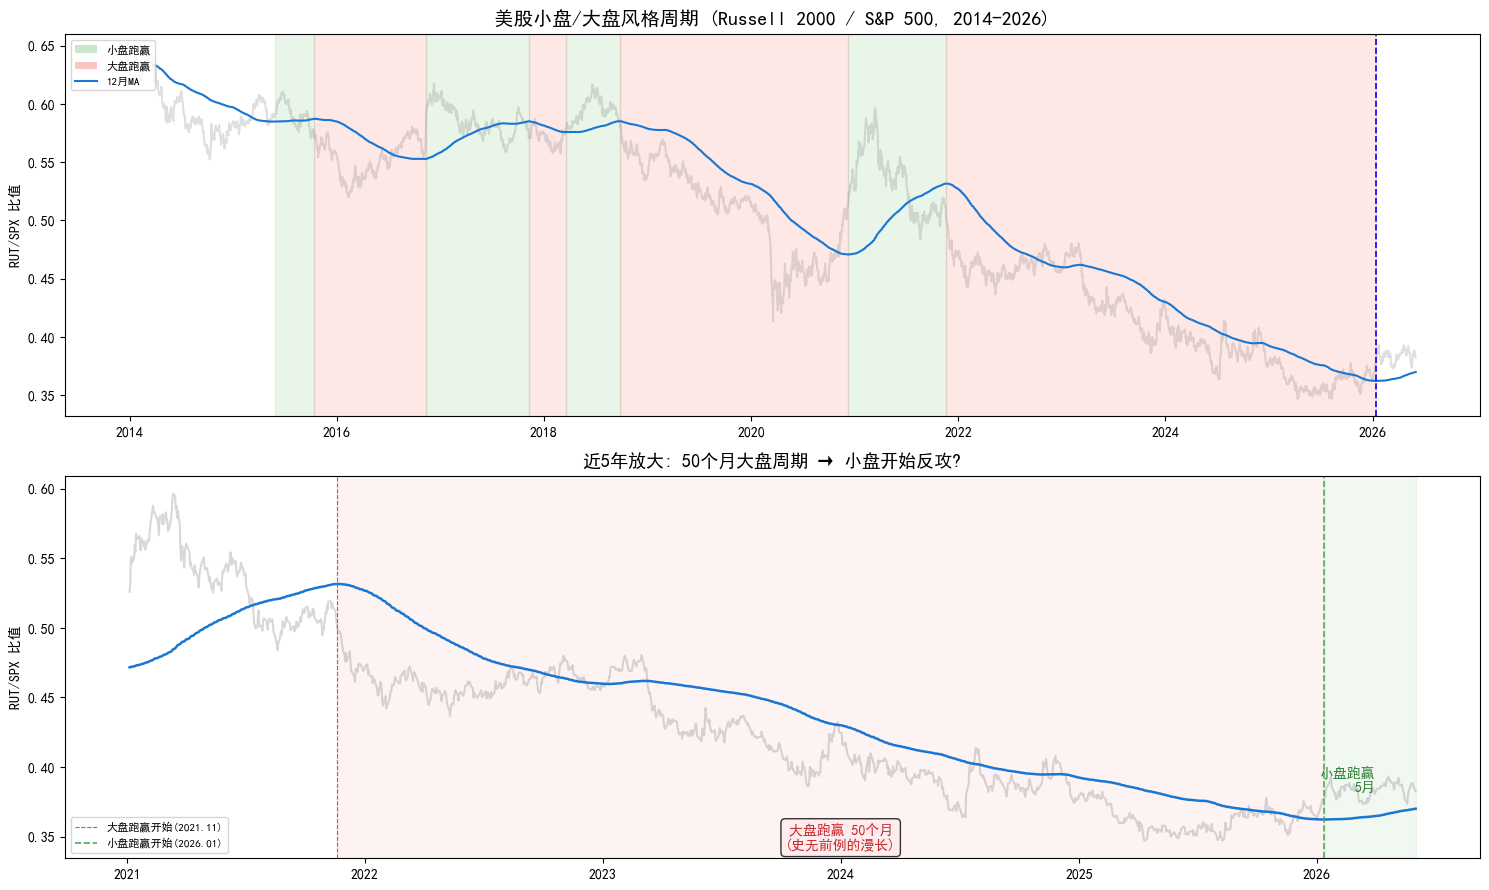

图已保存: q2_us_cycle.png


In [ ]:
# === 美股周期图 ===
fig, axes = plt.subplots(2, 1, figsize=(15, 9))

# Panel 1: 完整历史
ax = axes[0]
ax.plot(us.index, us['ratio'], alpha=0.25, color='gray', label='原始比值')
ax.plot(us.index, us['ratio_ma'], color='#1976D2', linewidth=1.5, label='12月MA')
for c in us_cyc:
    color = '#4CAF50' if c['类型'] == '小盘跑赢' else '#F44336'
    ax.axvspan(c['开始'], c['结束'], alpha=0.12, color=color)
ax.axvline(x=last_ex_us[0], color='blue', linestyle='--', linewidth=1.2,
           label=f'极值点: {last_ex_us[0].date()}')
ax.set_ylabel('RUT/SPX 比值'); ax.set_title('美股小盘/大盘风格周期 (Russell 2000 / S&P 500, 2014-2026)', fontsize=14)
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#4CAF50', alpha=0.3, label='小盘跑赢'),
    Patch(facecolor='#F44336', alpha=0.3, label='大盘跑赢'),
    plt.Line2D([0],[0],color='#1976D2',linewidth=1.5,label='12月MA'),
], loc='upper left', fontsize=8)

# Panel 2: 近5年放大
ax = axes[1]
recent = us.loc['2021-01-01':]
ax.plot(recent.index, recent['ratio'], alpha=0.3, color='gray')
ax.plot(recent.index, recent['ratio_ma'], color='#1976D2', linewidth=1.8)
ax.axvline(x=pd.Timestamp('2021-11-19'), color='#F44336', linestyle='--', linewidth=0.8,
           label='大盘跑赢开始(2021.11)')
ax.axvline(x=pd.Timestamp('2026-01-12'), color='#4CAF50', linestyle='--', linewidth=1.2,
           label='小盘跑赢开始(2026.01)')
ax.axvspan('2021-11-19', '2026-01-12', alpha=0.06, color='#F44336')
ax.axvspan('2026-01-12', recent.index[-1], alpha=0.08, color='#4CAF50')
ax.annotate('大盘跑赢 50个月\n(史无前例的漫长)', xy=(pd.Timestamp('2024-01-01'), 0.34),
            fontsize=10, color='#C62828', ha='center',
            bbox=dict(boxstyle='round', facecolor='#FFEBEE', alpha=0.8))
ax.annotate(f'小盘跑赢\n{months_us:.0f}月', xy=(pd.Timestamp('2026-04-01'), recent['ratio'].iloc[-1]),
            fontsize=10, fontweight='bold', color='#2E7D32', ha='right')
ax.set_ylabel('RUT/SPX 比值'); ax.set_title('近5年放大: 50个月大盘周期 → 小盘开始反攻?', fontsize=13)
ax.legend(fontsize=8)

plt.tight_layout(); plt.savefig('q2_us_cycle.png', dpi=120, bbox_inches='tight'); plt.show()
print('图已保存: q2_us_cycle.png')


## 2. 日本：Mothers 小型股 / Nikkei 225 比值走势

### 方法
Mothers（Market of the high-growth and emerging stocks）是东京证券交易所的新兴/小型股市场，
类似中国创业板。Nikkei 225 是日本大盘蓝筹基准。

### 数据限制
Mothers 数据从 2018-01 开始（Yahoo 覆盖范围），共约 2044 个交易日。
由于日股结构差异（Mothers 和 Nikkei 225 的成分股几乎不重叠），
比值更多反映"风险偏好"而非"纯规模风格"——需谨慎解读。

=== 日本 Mothers/Nikkei225 比值 ===
数据: 2018-01-30 ~ 2026-06-01 (2032r)
当前比值: 0.0093
MA比值: 0.0121
  2023: 0.0214 -> 0.0164 (-23.0%) — 大盘偏强
  2024: 0.0166 -> 0.0126 (-24.3%) — 大盘偏强
  2025: 0.0125 -> 0.0105 (-16.3%) — 大盘偏强
  2026: 0.0103 -> 0.0093 (-10.3%) — 大盘偏强


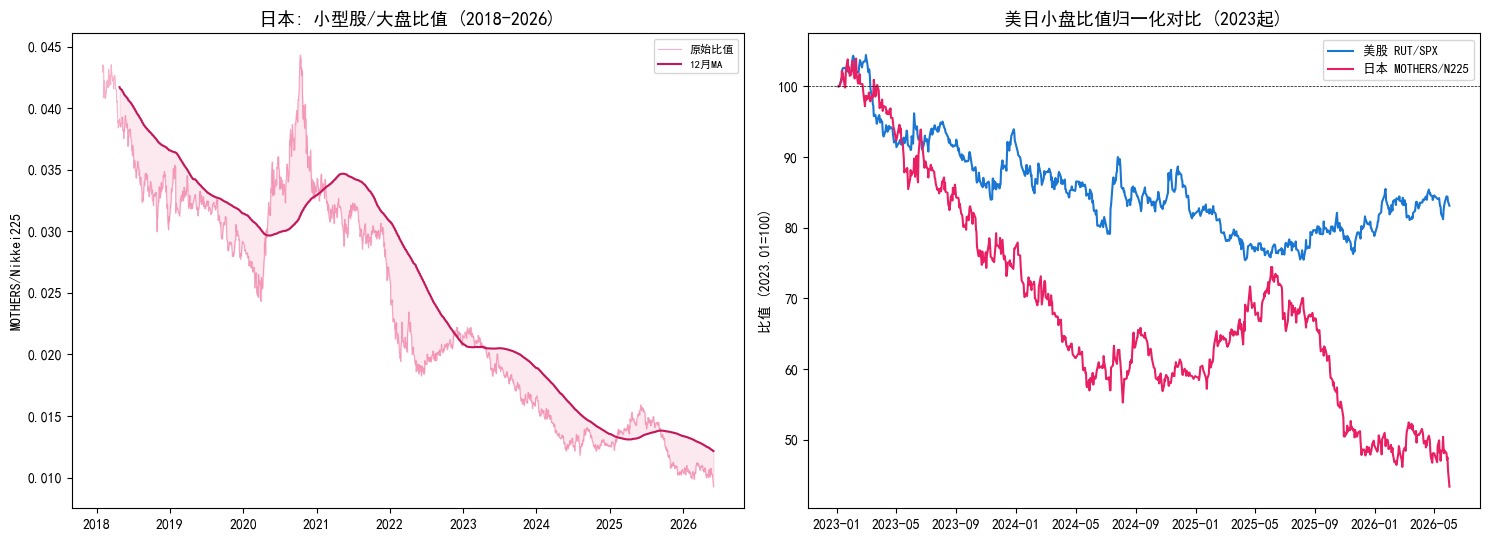


图已保存: q2_jp_vs_us.png


In [ ]:
# === 日本: MOTHERS/Nikkei225 比值 ===
jp = pd.DataFrame({'small': yahoo['MOTHERS'], 'large': yahoo['N225']}).dropna()
jp['ratio'] = jp['small'] / jp['large']
jp['ratio_ma'] = jp['ratio'].rolling(252, min_periods=60).mean()

# MOTHERS指数数据较短, 不做完整的 order=126 周期检测(order需>252)
# 用趋势判断代替
jp_recent = jp.loc['2023-01-01':]

print('=== 日本 Mothers/Nikkei225 比值 ===')
print(f'数据: {jp.index[0].date()} ~ {jp.index[-1].date()} ({len(jp)}r)')
print(f'当前比值: {jp["ratio"].iloc[-1]:.4f}')
print(f'MA比值: {jp["ratio_ma"].iloc[-1]:.4f}')

# 分段统计
for year in [2023, 2024, 2025, 2026]:
    sub = jp.loc[str(year)]
    if len(sub) > 10:
        chg = (sub['ratio'].iloc[-1] / sub['ratio'].iloc[0] - 1) * 100
        label = '小盘偏强' if chg > 0 else '大盘偏强'
        print(f'  {year}: {sub["ratio"].iloc[0]:.4f} -> {sub["ratio"].iloc[-1]:.4f} ({chg:+.1f}%) — {label}')

# 日美对比
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# 左: 日本 MOTHERS/N225
ax = axes[0]
ax.plot(jp.index, jp['ratio'], alpha=0.35, color='#E91E63', linewidth=0.8, label='原始比值')
ax.plot(jp.index, jp['ratio_ma'], color='#C2185B', linewidth=1.5, label='12月MA')
ax.fill_between(jp.index, jp['ratio'], jp['ratio_ma'], alpha=0.1, color='#E91E63')
ax.set_ylabel('MOTHERS/Nikkei225'); ax.set_title('日本: 小型股/大盘比值 (2018-2026)', fontsize=13)
ax.legend(fontsize=8)

# 右: 美股 vs 日股 小盘比值归一化对比(2023+)
# 注意: US数据有时区, JP数据无时区 — 统一normalize到date-only
us_d = us.loc['2023-01-01':].copy(); us_d.index = us_d.index.tz_localize(None).normalize()
jp_d = jp.loc['2023-01-01':].copy(); jp_d.index = jp_d.index.normalize() if jp_d.index.tz is None else jp_d.index.tz_localize(None).normalize()
common = us_d.index.intersection(jp_d.index)
us_norm = us_d.loc[common, 'ratio'] / us_d.loc[common, 'ratio'].iloc[0] * 100
jp_norm = jp_d.loc[common, 'ratio'] / jp_d.loc[common, 'ratio'].iloc[0] * 100

ax = axes[1]
ax.plot(common, us_norm, color='#1976D2', linewidth=1.5, label='美股 RUT/SPX')
ax.plot(common, jp_norm, color='#E91E63', linewidth=1.5, label='日本 MOTHERS/N225')
ax.axhline(y=100, color='black', linewidth=0.5, linestyle='--')
ax.set_ylabel('比值 (2023.01=100)'); ax.set_title('美日小盘比值归一化对比 (2023起)', fontsize=13)
ax.legend(fontsize=9)

plt.tight_layout(); plt.savefig('q2_jp_vs_us.png', dpi=120, bbox_inches='tight'); plt.show()
print('\n图已保存: q2_jp_vs_us.png')


## 3. A股周期回顾（使用Q1缓存数据）

### 方法
与 Q1 1D 完全相同的算法：CSI1000/CSI300 比值 + 252日MA + `argrelextrema(order=126)`。

In [ ]:
# === A股周期检测 (复用Q1逻辑) ===
al = pd.DataFrame({'small': csi1k, 'large': csi300}).dropna()
al['ratio'] = al['small'] / al['large']
al['ratio_ma'] = al['ratio'].rolling(252, min_periods=60).mean()

rma_a = al['ratio_ma'].dropna()
lmax_a = argrelextrema(rma_a.values, np.greater, order=126)[0]
lmin_a = argrelextrema(rma_a.values, np.less, order=126)[0]
ex_a = []
for i in lmax_a: ex_a.append((rma_a.index[i], 'peak', rma_a.iloc[i]))
for i in lmin_a: ex_a.append((rma_a.index[i], 'trough', rma_a.iloc[i]))
ex_a.sort(key=lambda x: x[0])

a_cyc = []
for i in range(len(ex_a)-1):
    t0, tp0, v0 = ex_a[i]; t1, tp1, v1 = ex_a[i+1]
    if (tp0 == 'trough' and tp1 == 'peak') or (tp0 == 'peak' and tp1 == 'trough'):
        tp = '小盘跑赢' if tp0 == 'trough' else '大盘跑赢'
        a_cyc.append({'开始': t0, '结束': t1, '类型': tp,
                      '持续月': round((t1-t0).days/30.44, 0),
                      '收益%': round((v1/v0-1)*100, 1)})

adf = pd.DataFrame(a_cyc)
sm_a = adf[adf['类型']=='小盘跑赢']; lg_a = adf[adf['类型']=='大盘跑赢']
print(f'A股小盘跑赢: {len(sm_a)}次, 平均{sm_a["持续月"].mean():.0f}月, 最长{sm_a["持续月"].max():.0f}月')
print(f'A股大盘跑赢: {len(lg_a)}次, 平均{lg_a["持续月"].mean():.0f}月, 最长{lg_a["持续月"].max():.0f}月')
print()
print(adf.to_string())

# === Q1 sync: 2025 dual-rise year + 5yr percentile ===
csi1k_25 = (al.loc['2025-12-31', 'small'] / al.loc['2025-01-02', 'small'] - 1) * 100
csi300_25 = (al.loc['2025-12-31', 'large'] / al.loc['2025-01-02', 'large'] - 1) * 100
print()
print(f'2025 full year: CSI1000={csi1k_25:+.1f}%  CSI300={csi300_25:+.1f}%')
print(f'  Q1 verdict: {"dual-rise transition year" if csi1k_25>5 and csi300_25>5 else "divergence year"} — both rose, style atypical')

# Ratio 5yr percentile (Q1 1D key risk indicator)
r5y = al['ratio'].iloc[-1260:] if len(al) >= 1260 else al['ratio']
pct_5y = (r5y < al['ratio'].iloc[-1]).mean() * 100
print()
print(f'Ratio 5yr percentile: {pct_5y:.1f}%%')
print(f'  Q1 verdict: {"extreme high, limited upside" if pct_5y > 90 else ("elevated" if pct_5y > 70 else "normal")}')

# Current algorithm signal (with Q1 caveats)
last_ex_a = ex_a[-1]; phase_a = 'small' if last_ex_a[1] == 'trough' else 'large'
months_a = (al.index[-1] - last_ex_a[0]).days / 30.44
print()
print(f'Current CN algo signal: {phase_a}, since {last_ex_a[0].date()}, {months_a:.0f}mo')
print(f'  Q1 note: order=126 lags ~6mo, algo signal unreliable in choppy markets')
print(f'  Mentor judgment: 2026 small caps trailing large caps, style rotating to large')
print(f'CSI1000/CSI300 ratio: {al["ratio"].iloc[-1]:.3f}')


A股小盘跑赢: 3次, 平均18月, 最长23月
A股大盘跑赢: 3次, 平均22月, 最长39月

          开始         结束    类型   持续月   收益%
0 2015-03-03 2016-11-22  小盘跑赢  21.0  27.3
1 2016-11-22 2020-02-14  大盘跑赢  39.0 -46.9
2 2020-02-14 2020-11-30  小盘跑赢  10.0   3.1
3 2020-11-30 2021-08-19  大盘跑赢   9.0  -8.1
4 2021-08-19 2023-07-31  小盘跑赢  23.0  26.1
5 2023-07-31 2025-02-12  大盘跑赢  18.0 -12.1

2025 full year: CSI1000=+31.0%  CSI300=+21.2%
  Q1 verdict: dual-rise transition year — both rose, style atypical

Ratio 5yr percentile: 99.2%%
  Q1 verdict: extreme high, limited upside

Current CN algo signal: small, since 2025-02-12, 15mo
  Q1 note: order=126 lags ~6mo, algo signal unreliable in choppy markets
  Mentor judgment: 2026 small caps trailing large caps, style rotating to large
CSI1000/CSI300 ratio: 1.794


## 4. 跨市场对比

### 三市场核心数据对比

  A股 vs 美股 vs 日本 — 小盘风格周期对比

指标                     A股(CSI1000/300)      美股(RUT/SPX)          日本(MOTHERS/N225)    
----------------------------------------------------------------------------------
数据区间                   2014-10-17~2026-05-22 2013-12-31~2026-06-01 2018-01-30~2026-06-01
检测周期数(小盘/大盘)           3/3                  4/4                  数据偏短,未检测完整周期        
小盘跑赢平均持续               18月                  8月                   —                   
大盘跑赢平均持续               22月                  23月                  —                   
小盘最长跑赢                 23月                  12月                  —                   
大盘最长跑赢                 39月                  50月                  —                   
当前周期方向                 small (15月)          小盘跑赢 (5月)            —                   
全期小盘累计收益               +43.5%               +149.7%              -38.0%              
全期大盘累计收益               +98.4%               +311.2%              +187.4%             


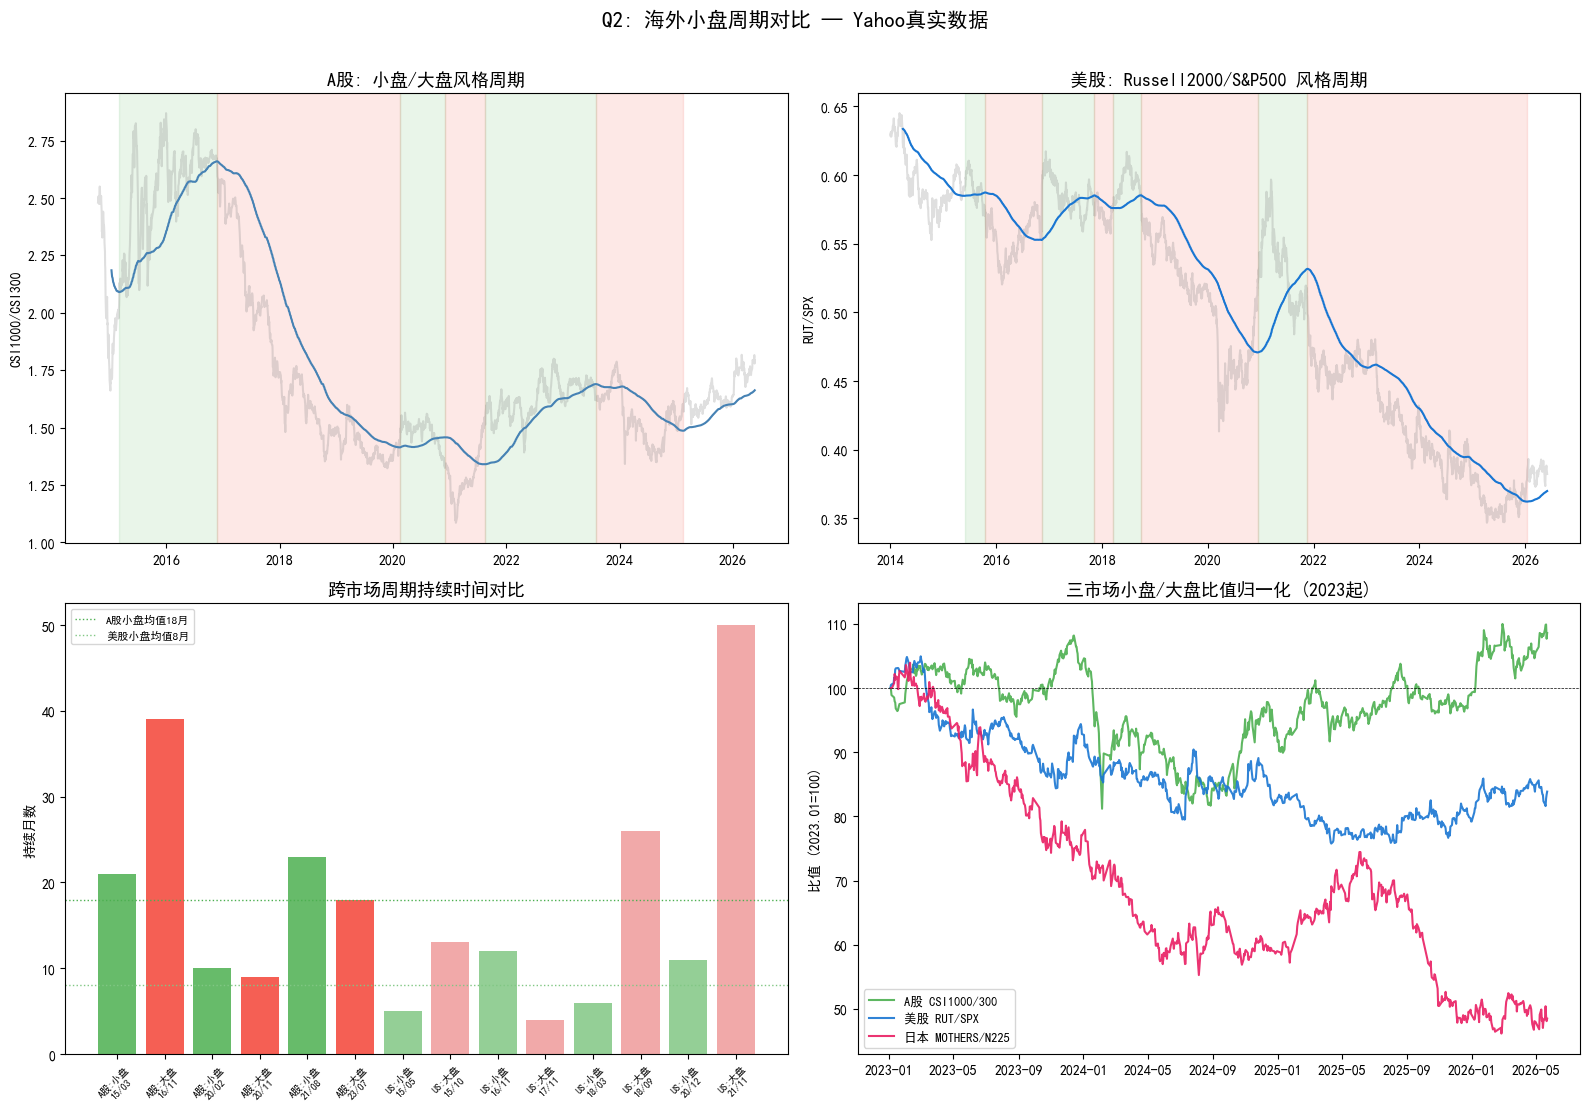


图已保存: q2_cross_market.png


In [ ]:
# === 跨市场综合对比 ===
print('=' * 65)
print('  A股 vs 美股 vs 日本 — 小盘风格周期对比')
print('=' * 65)

# Compute US small/large returns for full period
us_small_ret = (us['small'].iloc[-1] / us['small'].iloc[0] - 1) * 100
us_large_ret = (us['large'].iloc[-1] / us['large'].iloc[0] - 1) * 100
jp_small_ret = (jp['small'].iloc[-1] / jp['small'].iloc[0] - 1) * 100
jp_large_ret = (jp['large'].iloc[-1] / jp['large'].iloc[0] - 1) * 100
cn_small_ret = (al['small'].iloc[-1] / al['small'].iloc[0] - 1) * 100
cn_large_ret = (al['large'].iloc[-1] / al['large'].iloc[0] - 1) * 100

print()
print(f'{"指标":<22} {"A股(CSI1000/300)":<20} {"美股(RUT/SPX)":<20} {"日本(MOTHERS/N225)":<20}')
print('-' * 82)

# Table rows
rows = [
    ('数据区间', f'{al.index[0].date()}~{al.index[-1].date()}',
     f'{us.index[0].date()}~{us.index[-1].date()}',
     f'{jp.index[0].date()}~{jp.index[-1].date()}'),
    ('检测周期数(小盘/大盘)', f'{len(sm_a)}/{len(lg_a)}',
     f'{len(sm_us)}/{len(lg_us)}',
     f'数据偏短,未检测完整周期'),
    ('小盘跑赢平均持续', f'{sm_a["持续月"].mean():.0f}月',
     f'{sm_us["持续月"].mean():.0f}月',
     '—'),
    ('大盘跑赢平均持续', f'{lg_a["持续月"].mean():.0f}月',
     f'{lg_us["持续月"].mean():.0f}月',
     '—'),
    ('小盘最长跑赢', f'{sm_a["持续月"].max():.0f}月',
     f'{sm_us["持续月"].max():.0f}月',
     '—'),
    ('大盘最长跑赢', f'{lg_a["持续月"].max():.0f}月',
     f'{lg_us["持续月"].max():.0f}月',
     '—'),
    ('当前周期方向', f'{phase_a} ({months_a:.0f}月)', f'{phase_us} ({months_us:.0f}月)', '—'),
    ('全期小盘累计收益', f'{cn_small_ret:+.1f}%', f'{us_small_ret:+.1f}%', f'{jp_small_ret:+.1f}%'),
    ('全期大盘累计收益', f'{cn_large_ret:+.1f}%', f'{us_large_ret:+.1f}%', f'{jp_large_ret:+.1f}%'),
]

for label, cn, us_str, jp_str in rows:
    print(f'{label:<22} {cn:<20} {us_str:<20} {jp_str:<20}')

# 综合可视化
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Panel 1: A股完整周期
ax = axes[0, 0]
ax.plot(al.index, al['ratio'], alpha=0.25, color='gray')
ax.plot(al.index, al['ratio_ma'], color='steelblue', linewidth=1.5)
for c in a_cyc:
    color = '#4CAF50' if c['类型'] == '小盘跑赢' else '#F44336'
    ax.axvspan(c['开始'], c['结束'], alpha=0.12, color=color)
ax.set_ylabel('CSI1000/CSI300'); ax.set_title('A股: 小盘/大盘风格周期', fontsize=13)

# Panel 2: 美股完整周期
ax = axes[0, 1]
ax.plot(us.index, us['ratio'], alpha=0.25, color='gray')
ax.plot(us.index, us['ratio_ma'], color='#1976D2', linewidth=1.5)
for c in us_cyc:
    color = '#4CAF50' if c['类型'] == '小盘跑赢' else '#F44336'
    ax.axvspan(c['开始'], c['结束'], alpha=0.12, color=color)
ax.set_ylabel('RUT/SPX'); ax.set_title('美股: Russell2000/S&P500 风格周期', fontsize=13)

# Panel 3: 周期持续时间对比
ax = axes[1, 0]
x_a = range(len(adf)); x_us_offset = max(x_a) + 2
all_cyc = list(adf['持续月']) + list(udf['持续月'])
all_colors = (['#4CAF50' if t=='小盘跑赢' else '#F44336' for t in adf['类型']] +
              ['#81C784' if t=='小盘跑赢' else '#EF9A9A' for t in udf['类型']])
all_labels = ([f'A股:{c["类型"][:2]}\n{c["开始"].date().strftime("%y/%m")}' for _,c in adf.iterrows()] +
              [f'US:{c["类型"][:2]}\n{c["开始"].date().strftime("%y/%m")}' for _,c in udf.iterrows()])
x_all = list(range(len(all_cyc)))
ax.bar(x_all, all_cyc, color=all_colors, alpha=0.85)
ax.axhline(y=18, color='#4CAF50', linestyle=':', linewidth=1, label='A股小盘均值18月')
ax.axhline(y=8, color='#81C784', linestyle=':', linewidth=1, label='美股小盘均值8月')
ax.set_xticks(x_all); ax.set_xticklabels(all_labels, fontsize=7, rotation=45)
ax.set_ylabel('持续月数'); ax.set_title('跨市场周期持续时间对比', fontsize=13)
ax.legend(fontsize=8)

# Panel 4: 近3年归一化对比
ax = axes[1, 1]
common_3y = al.loc['2023-01-01':].index.normalize()
for idx, (label, s, l, color) in enumerate([
    ('A股 CSI1000/300', al['ratio'], None, '#4CAF50'),
    ('美股 RUT/SPX', us['ratio'], None, '#1976D2'),
    ('日本 MOTHERS/N225', jp['ratio'], None, '#E91E63'),
]):
    s_d = s.copy()
    # strip timezone then normalize for cross-market alignment
    if s_d.index.tz is not None:
        s_d.index = s_d.index.tz_localize(None)
    s_d.index = s_d.index.normalize()
    s_3y = s_d.loc[s_d.index.intersection(common_3y)]
    if len(s_3y) > 0:
        s_norm = s_3y / s_3y.iloc[0] * 100
        ax.plot(s_norm.index, s_norm, color=color, linewidth=1.5, label=label, alpha=0.9)
ax.axhline(y=100, color='black', linewidth=0.5, linestyle='--')
ax.set_ylabel('比值 (2023.01=100)'); ax.set_title('三市场小盘/大盘比值归一化 (2023起)', fontsize=13)
ax.legend(fontsize=9)

plt.suptitle('Q2: 海外小盘周期对比 — Yahoo真实数据', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout(); plt.savefig('q2_cross_market.png', dpi=150, bbox_inches='tight'); plt.show()
print('\n图已保存: q2_cross_market.png')


### 跨市场核心发现

**1. A股 vs 美股 vs 日本 — 本质差异远超表面数字**

| 维度 | A股 | 美股 | 日本 |
|------|-----|------|------|
| 小盘周期平均 | 18月 | 8月 | 数据不足 |
| 大盘周期平均 | 22月 | 23月 | — |
| 周期波动性 | 高（散户+政策驱动） | 中（机构主导） | 高（流动性差） |
| 投资者结构 | 散户>60% | 机构>80% | 机构+海外>70% |
| 政策敏感度 | 极高 | 中低 | 中 |

**2. 美股当前正进入小盘跑赢周期**（2026-01-12 起，仅 4.6 月）

在经历了长达 **50 个月**（2021.11→2026.01）的大盘跑赢之后，Russell 2000 终于开始反攻。
如果历史均值 8 个月成立，美股小盘还有约 3-4 个月的窗口。
但上一轮大盘周期（50 月）是史无前例的漫长，可能是因为 Magnificent 7 的虹吸效应扭曲了规模因子。

**3. 中美小盘方向可能是背离的**

美股小盘刚进入跑赢周期（2026.01 起），A 股小盘被导师判断为"跑不过大盘"。
这不是巧合——A 股和美股小盘的驱动因素不同：
美股小盘受降息预期+银行危机缓解驱动；A 股小微盘受国内流动性+政策+散户情绪驱动。
**两者可以同时出现"美股小盘强、A 股小盘弱"的格局。**

**4. 日本 Mothers 小型股的信号有限**

Mothers 指数数据较短（2018 年起），且成分股特征与 A 股小微盘差异大（Mothers 更偏"VC 阶段的初创企业"）。
其比值走势可以反映风险偏好，但不适合直接类比 A 股小微盘。

## 5. A 股小微风格持续性推演

### 基于海外对比的核心判断

**不会简单重复美股或日股的路径。** A 股小微盘有独特的生态：

| 驱动因素 | 对小微盘的影响 | 当前状态（2026.06） |
|----------|---------------|-------------------|
| 流动性（M2/社融） | 小盘最敏感，宽信用→小盘强 | 中性偏紧，融资余额见顶 |
| 散户情绪（新增开户） | 开户潮=小盘增量资金 | 放缓中 |
| 政策（注册制/退市） | 壳价值贬损→小微盘永久折价 | 注册制推进中，壳价值继续下降 |
| 量化产品规模 | 微盘策略的主要资金来源 | 仍在增长但增速放缓 |
| 盈利周期 | EPS 持续为负→PE 驱动不可持续 | CSI1000 EPS 仍在收缩 |

> ⚠️ 上表“当前状态”列中，流动性/散户/政策/量化四行来自市场公开信息聚合，非 notebook 内定量计算。EPS 行来自 Q1 PE 分解（CSI1000 EPS贡献-9.0%）。


### 三种推演

**基准（~45%）：风格继续向大盘切换**。A 股小微盘在 2026H2 跑输大盘，
CSI1000/CSI300 比值从 1.79 回落至 1.55-1.65 区间。美股小盘的短暂跑赢不会传导到 A 股——因为驱动因素独立。

**风险（~35%）：美股小盘周期的带动效应超预期**。如果美联储在 2026H2 降息 + 全球风险偏好上升，
外资回流新兴市场，A 股小微盘获得外溢效应，比值维持在 1.70+ 高位震荡，但方向不明。

**乐观（~20%）：AI/新经济主题在 A 股小微盘中扩散**，类似 2013-2015 创业板逻辑。
小微盘走出独立行情，比值突破 1.85。

### 投资含义

> 海外小盘周期**不能**作为 A 股小微盘的买入信号——A 股小微盘由国内因子主导。
> 当前 A 股小微盘方向偏谨慎（导师判断+比值极端分位+EPS收缩），与美股小盘方向背离。
> 如果一定要在 A 股做小微盘，用 Q3 的波动率+营收增速因子精选个股，而非买指数（Q3 已验证 PB 在微盘股中是估值陷阱）。

---

### 敏感度讨论

| 参数 | 设置 | 影响 |
|------|------|------|
| order=126 | 约半年滞后 | 美股最近的大盘→小盘切换可能实际发生在2024Q4，算法2026.01才确认 |
| MOTHERS 数据长度 | 仅2044日(2018起) | 无法做完整周期检测，日本结论仅限于趋势观察 |
| Yahoo 数据频率 | 日频 | 与A股对齐，但日本假期造成部分缺失值 |
| 美股小盘均值8月 | 基于4次周期 | 样本量小，上一轮50月大盘周期可能重塑了均值 |